In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
birds_df = pd.read_csv(
    "../cleaned_data/birds_cleaned.csv"
)

birds_df.head()

,AOU_Code,AcceptedTSN,Admin_Sheet,Admin_Unit_Code,Common_Name,Date,Distance,Disturbance,End_Time,Flyover_Observed,Habitat,Humidity,ID_Method,Initial_Three_Min_Cnt,Interval_Length,Location_Type,NPSTaxonCode,Observer,PIF_Watchlist_Status,Plot_Name,Regional_Stewardship_Status,Scientific_Name,Sex,Site_Name,Sky,Start_Time,Temperature,Visit,Wind,Year,Month,Month_Name,Quarter,Season
0,EATO,179276.0,ANTI,ANTI,Eastern Towhee,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Singing,True,0-2.5 min,Forest,83803.0,Elizabeth Oswald,False,ANTI-0036,True,Pipilo erythrophthalmus,Undetermined,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
1,WBNU,178775.0,ANTI,ANTI,White-breasted Nuthatch,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Calling,True,0-2.5 min,Forest,90935.0,Elizabeth Oswald,False,ANTI-0036,False,Sitta carolinensis,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
2,RBWO,178195.0,ANTI,ANTI,Red-bellied Woodpecker,2018-05-22,50 - 100 Meters,No effect on count,06:29:00,False,Forest,79.400002,Calling,False,2.5 - 5 min,Forest,84865.0,Elizabeth Oswald,False,ANTI-0036,False,Melanerpes carolinus,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
3,OROR,179064.0,ANTI,ANTI,Orchard Oriole,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Singing,False,2.5 - 5 min,Forest,93634.0,Elizabeth Oswald,False,ANTI-0036,False,Icterus spurius,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
4,NOMO,178620.0,ANTI,ANTI,Northern Mockingbird,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Visualization,False,2.5 - 5 min,Forest,88394.0,Elizabeth Oswald,False,ANTI-0036,False,Mimus polyglottos,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring


In [3]:
birds_df["Temperature"].describe()

count    15372.000000
mean        22.493826
std          4.193138
min         11.000000
25%         19.700001
50%         22.200001
75%         25.000000
max         37.299999
Name: Temperature, dtype: float64

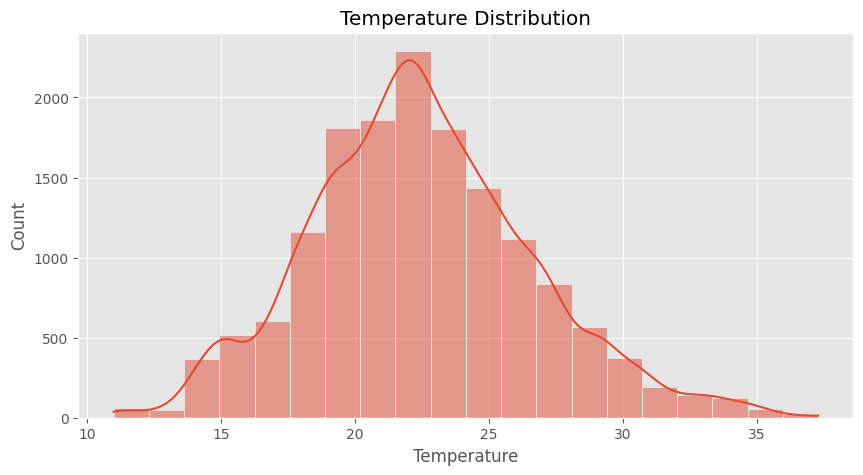

<Figure size 640x480 with 0 Axes>

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    birds_df["Temperature"],
    bins=20,
    kde=True
)

plt.title(
    "Temperature Distribution"
)

plt.show()

plt.savefig(
    "../images/environmental/temperature_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [5]:
birds_df["Humidity"].describe()

count    15372.000000
mean        74.159335
std         12.168509
min          7.300000
25%         68.000000
50%         76.599998
75%         83.400002
max         98.800003
Name: Humidity, dtype: float64

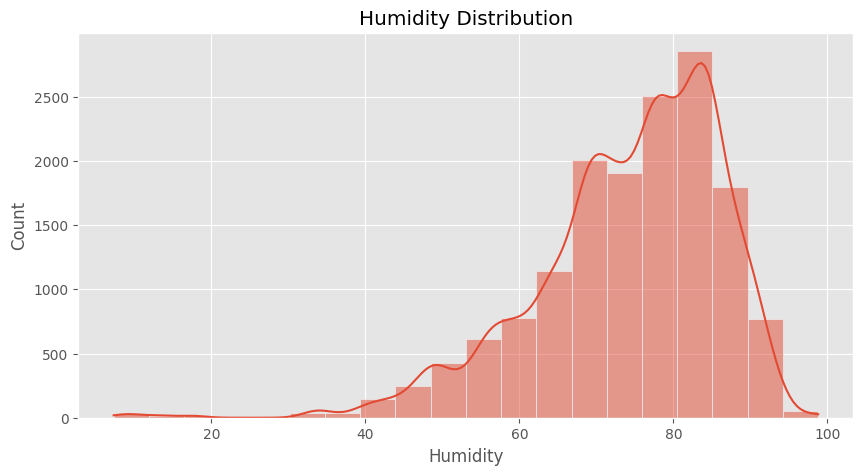

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(
    birds_df["Humidity"],
    bins=20,
    kde=True
)

plt.title(
    "Humidity Distribution"
)

plt.show()

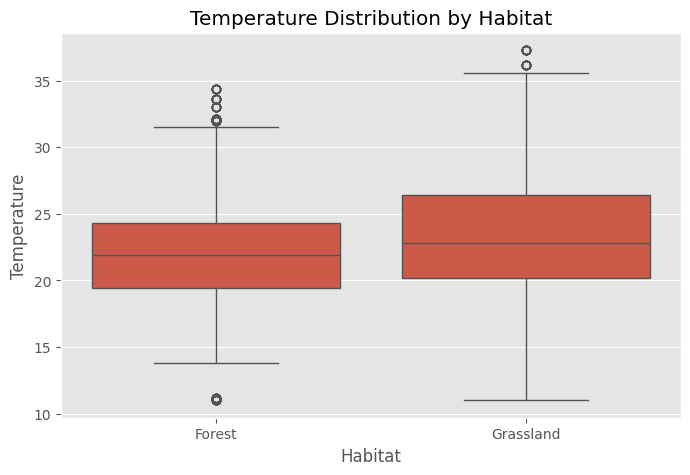

In [7]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=birds_df,
    x="Habitat",
    y="Temperature"
)

plt.title(
    "Temperature Distribution by Habitat"
)

plt.show()

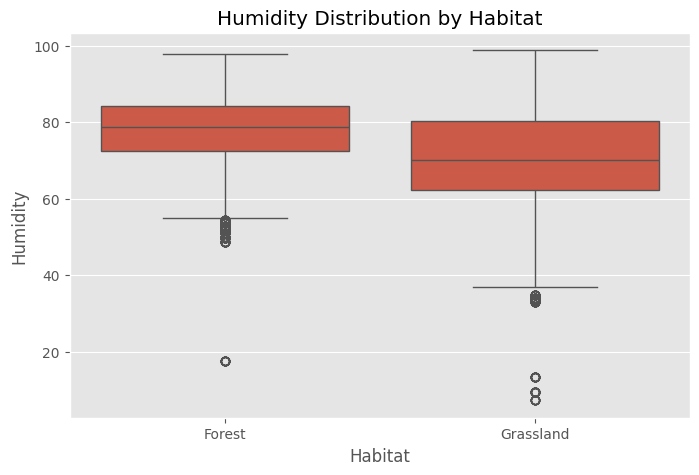

<Figure size 640x480 with 0 Axes>

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=birds_df,
    x="Habitat",
    y="Humidity"
)

plt.title(
    "Humidity Distribution by Habitat"
)

plt.show()

plt.savefig(
    "../images/environmental/humidity_distribution_by_habitat.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [9]:
sky_counts = (
    birds_df["Sky"]
    .value_counts()
    .reset_index()
)

sky_counts.columns = [
    "Sky_Condition",
    "Count"
]

sky_counts

,Sky_Condition,Count
0,Partly Cloudy,6172
1,Clear or Few Clouds,5333
2,Cloudy/Overcast,2917
3,Fog,598
4,Mist/Drizzle,352


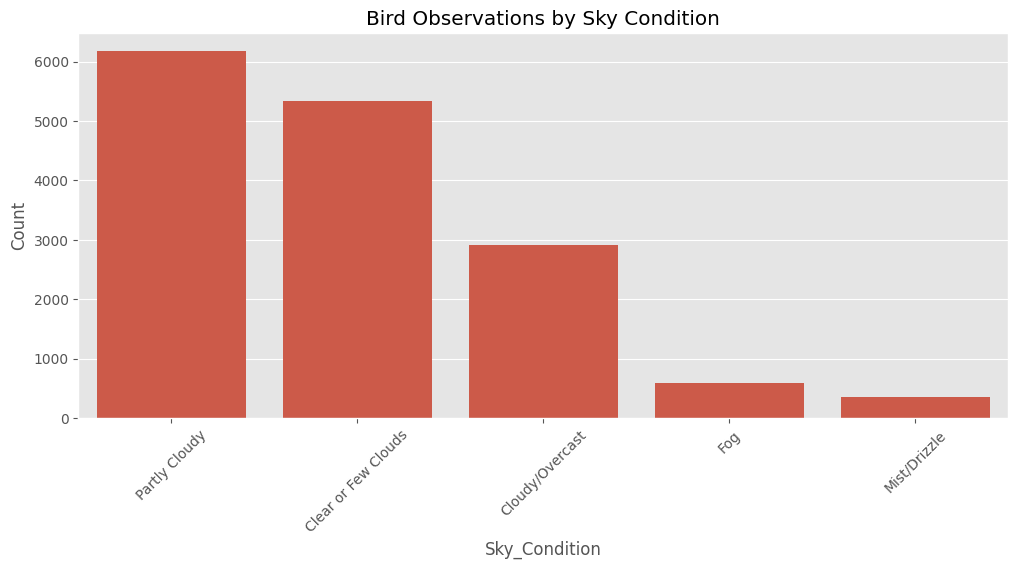

<Figure size 640x480 with 0 Axes>

In [20]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=sky_counts,
    x="Sky_Condition",
    y="Count"
)

plt.xticks(rotation=45)

plt.title(
    "Bird Observations by Sky Condition"
)

plt.show()

plt.savefig(
    "../images/environmental/sky_condition_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [11]:
wind_counts = (
    birds_df["Wind"]
    .value_counts()
    .reset_index()
)

wind_counts.columns = [
    "Wind_Condition",
    "Count"
]

wind_counts

,Wind_Condition,Count
0,Light air movement (1-3 mph) smoke drifts,7636
1,Calm (< 1 mph) smoke rises vertically,4210
2,Light breeze (4-7 mph) wind felt on face,3161
3,"Gentle breeze (8-12 mph), leaves in motion",365


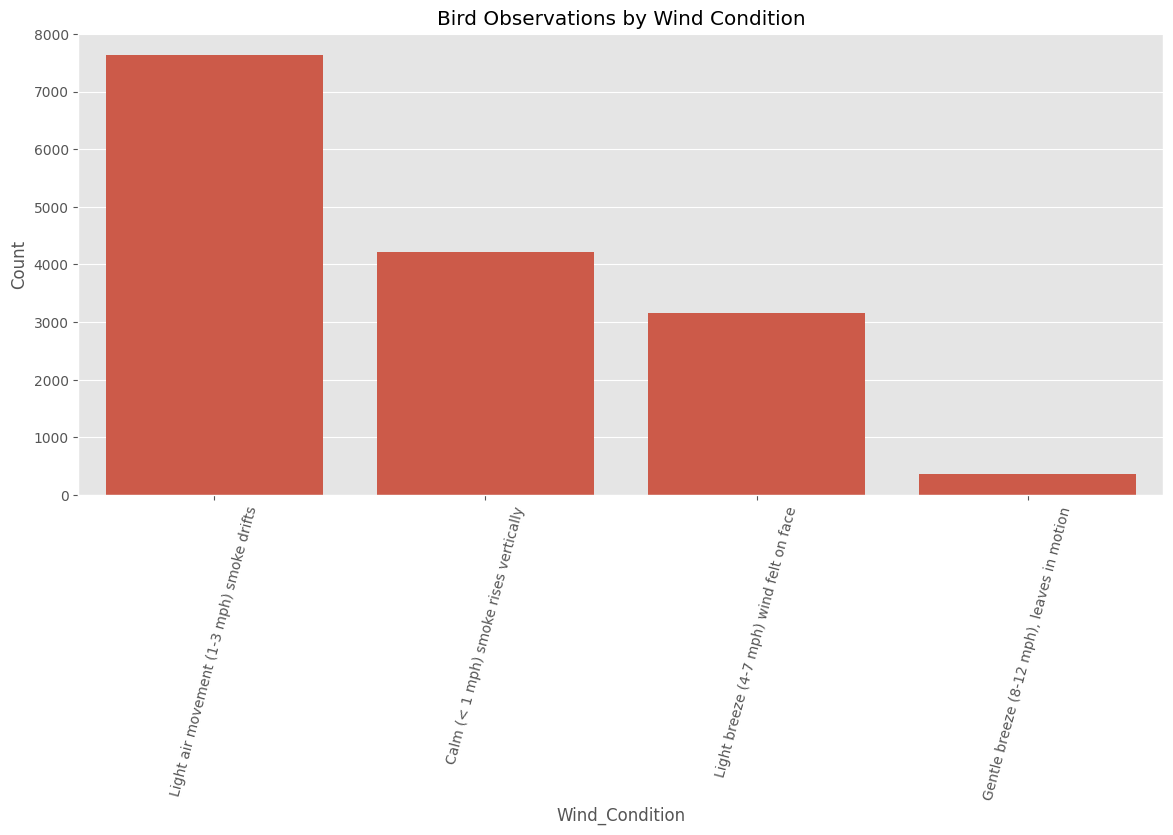

<Figure size 640x480 with 0 Axes>

In [21]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=wind_counts,
    x="Wind_Condition",
    y="Count"
)

plt.xticks(rotation=75)

plt.title(
    "Bird Observations by Wind Condition"
)

plt.show()

plt.savefig(
    "../images/environmental/wind_condition_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [13]:
disturbance_counts = (
    birds_df["Disturbance"]
    .value_counts()
    .reset_index()
)

disturbance_counts.columns = [
    "Disturbance",
    "Count"
]

disturbance_counts

,Disturbance,Count
0,No effect on count,7525
1,Slight effect on count,5840
2,Moderate effect on count,1577
3,Serious effect on count,430


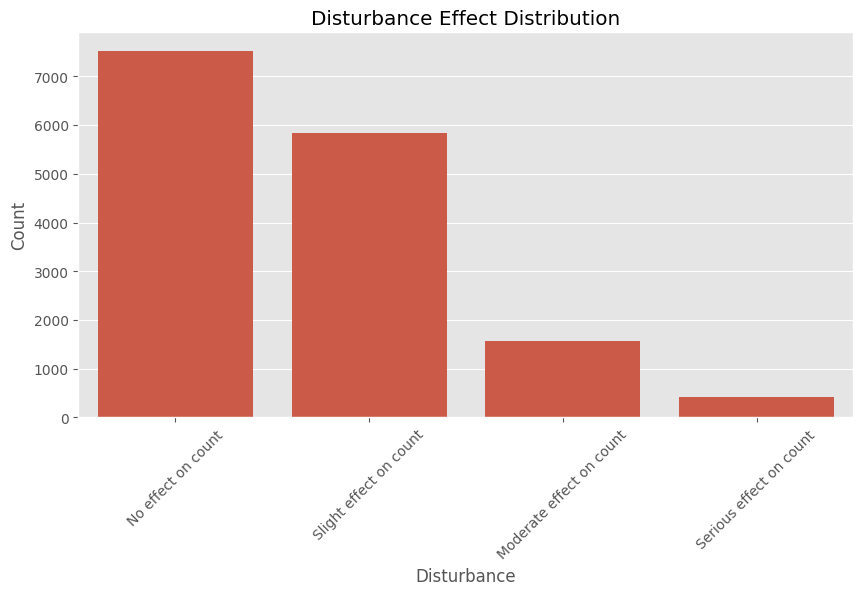

<Figure size 640x480 with 0 Axes>

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=disturbance_counts,
    x="Disturbance",
    y="Count"
)

plt.xticks(rotation=45)

plt.title(
    "Disturbance Effect Distribution"
)

plt.show()


plt.savefig(
    "../images/environmental/disturbance_effect_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [15]:
corr_df = birds_df[
    [
        "Temperature",
        "Humidity",
        "Visit",
        "Year"
    ]
]

corr_df.corr()

,Temperature,Humidity,Visit,Year
Temperature,1.000000,-0.337616,0.324717,NaN
Humidity,-0.337616,1.000000,0.027426,NaN
Visit,0.324717,0.027426,1.000000,NaN
Year,NaN,NaN,NaN,NaN


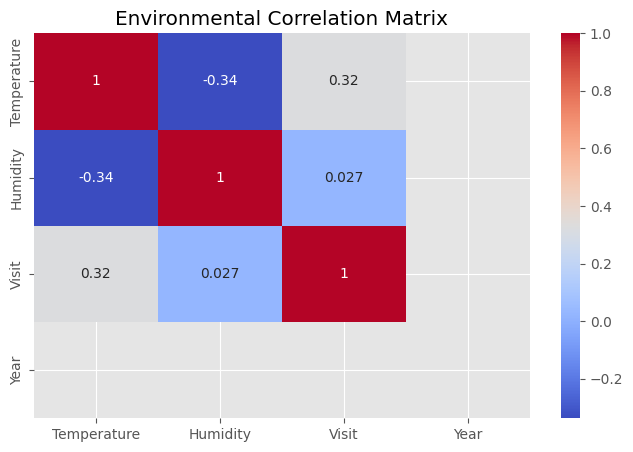

<Figure size 640x480 with 0 Axes>

In [23]:
plt.figure(figsize=(8,5))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Environmental Correlation Matrix"
)

plt.show()

plt.savefig(
    "../images/environmental/correlation_matrix.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

## Environmental Analysis Findings

### 1. Temperature Analysis
- Most bird observations occurred between 18°C and 27°C.
- Peak observation frequency occurred around 22°C–24°C.
- Extremely low and high temperatures had fewer observations.

### 2. Humidity Analysis
- Most observations occurred at humidity levels between 65% and 90%.
- Peak activity was concentrated around 75%–85% humidity.
- Bird observations decrease at very low humidity levels.

### 3. Habitat Environmental Comparison
#### Temperature
- Grassland habitats showed slightly higher temperature variability.
- Forest habitats exhibited more stable temperature conditions.

#### Humidity
- Forest habitats generally maintained higher humidity levels.
- Grasslands showed wider humidity fluctuations.

### 4. Sky Condition Analysis
Observation counts by sky condition:

1. Partly Cloudy (~6200)
2. Clear or Few Clouds (~5300)
3. Cloudy/Overcast (~2900)
4. Fog (~600)
5. Mist/Drizzle (~350)

Bird activity was highest during partly cloudy and clear weather conditions.

### 5. Wind Condition Analysis
Most observations occurred during:

1. Light air movement (1–3 mph)
2. Calm conditions (<1 mph)
3. Light breeze (4–7 mph)
4. Gentle breeze (8–12 mph)

Bird detection rates decrease as wind intensity increases.

### 6. Disturbance Analysis
Observation counts:

- No effect on count (~7500)
- Slight effect on count (~5800)
- Moderate effect on count (~1600)
- Serious effect on count (~400)

Most bird observations were recorded under low-disturbance conditions.

### 7. Correlation Analysis

Temperature vs Humidity:
- Moderate negative relationship (-0.34)

Temperature vs Visit:
- Weak positive relationship (0.32)

Humidity vs Visit:
- Almost no relationship (0.03)

No strong environmental correlations were observed.

Bird observations are highest under:

✓ Moderate temperatures
✓ High humidity
✓ Low wind conditions
✓ Low disturbance conditions
✓ Partly cloudy or clear skies

Bird detection and activity are strongly influenced
by favorable environmental conditions.

Surveys conducted during calm weather,
moderate temperature, and low disturbance periods
are likely to produce the highest observation rates.